# Notebook 20 — Pillar F: Cosmic Chronometer H(z) Prediction

Following Reviewer 1 #6 ("the numerical evidence must be quantitatively much more compelling"), we move beyond the 4-anchor $H_0$ fit of Pillar~C and test the DSC relaxation $H(t) = H_\infty + \beta/\ln^2(t/t_P)$ against the **standard cosmic chronometer (CC) compilation** of 32 model-independent $H(z)$ measurements from differential galaxy ages (Moresco 2022 review and references therein).

**Why this is a non-trivial test.** The 4-anchor $H_0$ fit of Pillar~C had only 2 dof, so any smooth monotone decay would fit. The 32-point CC sample stretches over $z \in [0.07, 1.97]$, has 30 dof after fitting two parameters, and is **independent of the SH0ES local distance ladder, BAO, and CMB**, so it provides an orthogonal falsifier.

**Headline result preview.** The DSC fit yields $H_\infty, \beta$ that we will compare to: (a) constant $\Lambda$CDM $H_0$, (b) flat $\Lambda$CDM with $H_0 = 67.4, \Omega_m = 0.315$, (c) Pillar~C's previously-fit ($H_\infty = 104.5, \beta = -6.24$) without refit, to check whether the same parameters generalize.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({"font.family":"serif", "font.size":10, "figure.dpi":140})

# Planck time conversion: t/t_P at redshift z
t_P    = 5.391e-44       # s
t_now  = 4.354e17        # s, age of universe (Planck 2018, ~13.8 Gyr)
n_now  = t_now / t_P
ln_n_now = np.log(n_now)
print(f'n_now = {n_now:.3e}, ln n_now = {ln_n_now:.2f}')

n_now = 8.076e+60, ln n_now = 140.24


## 1. The 32-point cosmic chronometer compilation

All values from differential galaxy aging (model-independent), as compiled in Moresco (2022) [arXiv:2205.05701] and references therein. Original sources: Jimenez+ 2003, Simon+ 2005, Stern+ 2010, Moresco+ 2012/2015/2016, Zhang+ 2014, Ratsimbazafy+ 2017, Borghi+ 2022a.

In [2]:
cc = np.array([
    # z       H(z)    sigma   reference
    [0.0700,  69.0,  19.6 ],   # Zhang 2014
    [0.0900,  69.0,  12.0 ],   # Simon 2005
    [0.1200,  68.6,  26.2 ],   # Zhang 2014
    [0.1700,  83.0,   8.0 ],   # Simon 2005
    [0.1791,  75.0,   4.0 ],   # Moresco 2012
    [0.1993,  75.0,   5.0 ],   # Moresco 2012
    [0.2000,  72.9,  29.6 ],   # Zhang 2014
    [0.2700,  77.0,  14.0 ],   # Simon 2005
    [0.2800,  88.8,  36.6 ],   # Zhang 2014
    [0.3519,  83.0,  14.0 ],   # Moresco 2012
    [0.3802,  83.0,  13.5 ],   # Moresco 2016
    [0.4000,  95.0,  17.0 ],   # Simon 2005
    [0.4004,  77.0,  10.2 ],   # Moresco 2016
    [0.4247,  87.1,  11.2 ],   # Moresco 2016
    [0.4497,  92.8,  12.9 ],   # Moresco 2016
    [0.4783,  80.9,   9.0 ],   # Moresco 2016
    [0.4800,  97.0,  62.0 ],   # Stern 2010
    [0.5929,  104.0, 13.0 ],   # Moresco 2012
    [0.6797,  92.0,   8.0 ],   # Moresco 2012
    [0.7500,  98.8,  33.6 ],   # Borghi 2022a
    [0.7812,  105.0, 12.0 ],   # Moresco 2012
    [0.8754,  125.0, 17.0 ],   # Moresco 2012
    [0.8800,  90.0,  40.0 ],   # Stern 2010
    [0.9000,  117.0, 23.0 ],   # Simon 2005
    [1.0370,  154.0, 20.0 ],   # Moresco 2012
    [1.3000,  168.0, 17.0 ],   # Simon 2005
    [1.3630,  160.0, 33.6 ],   # Moresco 2015
    [1.4300,  177.0, 18.0 ],   # Simon 2005
    [1.4650,  150.0, 50.0 ],   # Stern 2010
    [1.5300,  140.0, 14.0 ],   # Simon 2005
    [1.7500,  202.0, 40.0 ],   # Simon 2005
    [1.9650,  186.5, 50.4 ],   # Moresco 2015
])
z_data, H_data, H_err = cc[:,0], cc[:,1], cc[:,2]
print(f'CC sample: {len(z_data)} points, z in [{z_data.min():.3f}, {z_data.max():.3f}]')

CC sample: 32 points, z in [0.070, 1.965]


## 2. Three competing models

**M0 (constant)**: $H(z) = H_0$ (1 parameter, sanity null).

**M1 ($\Lambda$CDM)**: $H(z) = H_0\sqrt{\Omega_m (1+z)^3 + (1-\Omega_m)}$ (2 parameters).

**M2 (DSC)**: $H(t) = H_\infty + \beta/\ln^2(t/t_P)$, where the cosmic-time / redshift conversion uses the $\Lambda$CDM age relation $t(z) = t_{\rm now}/(1+z)^{3/2}$ (matter-dominated approximation, sufficient at $z > 0.1$). This is the same DSC functional form fit in Pillar~C.

In [3]:
def H_LCDM(z, H0, Om):
    return H0 * np.sqrt(Om*(1+z)**3 + (1-Om))

# Use Pillar C's exact convention: cosmic age t(z) computed from matter-dominated
# t(z) = t_now / (1+z)^(3/2), and DSC fit form  H = H_inf + beta * (1e5 / ln^2(t/t_P))
# (the factor 1e5 is absorbed into beta in Pillar C, where beta_PillarC = -6.24).
def H_DSC(z, H_inf, beta_scaled):
    n = (t_now / (1+z)**1.5) / t_P
    xi_scaled = 1e5 / np.log(n)**2  # same convention as Pillar C
    return H_inf + beta_scaled * xi_scaled

def chi2(model, params, z=z_data, H=H_data, sig=H_err):
    return np.sum(((H - model(z, *params))/sig)**2)

res0 = minimize(lambda p: np.sum(((H_data - p[0])/H_err)**2), [70.0])
res1 = minimize(lambda p: chi2(H_LCDM, p), [70.0, 0.3], bounds=[(50,90),(0.1,0.5)])
res2 = minimize(lambda p: chi2(H_DSC, p), [70.0, 5.0], bounds=[(0,150),(-200,200)])

for name, res, dof_offset in [('M0 (const)', res0, 1), ('M1 (LCDM)', res1, 2), ('M2 (DSC)', res2, 2)]:
    chi2v = res.fun
    dof = len(z_data) - dof_offset
    aic = chi2v + 2*dof_offset
    bic = chi2v + dof_offset*np.log(len(z_data))
    print(f'{name:14s}: chi2 = {chi2v:7.2f}, chi2/dof = {chi2v/dof:.3f}, AIC = {aic:.2f}, BIC = {bic:.2f}, params = {res.x}')

# Pillar C reuse: H_inf=104.5, beta=-6.24 (no refit, exact Pillar C numbers)
chi2_pc = chi2(H_DSC, [104.5, -6.24])
print(f'\nPillar C parameters (no refit, H_inf=104.5, beta_scaled=-6.24):')
print(f'  chi2 = {chi2_pc:.2f}, chi2/dof = {chi2_pc/(len(z_data)-2):.3f}')

# Diagnostic: how much does xi_scaled vary over the CC sample vs across the 4 anchors?
def xi_at(t_yr): return 1e5 / np.log(t_yr*3.1536e7/t_P)**2
xi_cc_lo = xi_at(t_now/3.1536e7/(1+z_data.min())**1.5)
xi_cc_hi = xi_at(t_now/3.1536e7/(1+z_data.max())**1.5)
xi_pc_lo = xi_at(13.8e9)  # SH0ES anchor
xi_pc_hi = xi_at(3.8e5)   # Planck anchor
print(f'\nDiagnostic: xi_scaled = 1e5/ln^2(t/t_P) leverage')
print(f'  CC sample (z in [{z_data.min():.2f},{z_data.max():.2f}]):  xi range [{xi_cc_lo:.4f}, {xi_cc_hi:.4f}], span = {xi_cc_hi-xi_cc_lo:.4f}')
print(f'  4 Pillar-C anchors (t in [380kyr, 13.8Gyr]): xi range [{xi_pc_lo:.4f}, {xi_pc_hi:.4f}], span = {xi_pc_hi-xi_pc_lo:.4f}')
print(f'  Ratio: Pillar C had {(xi_pc_hi-xi_pc_lo)/(xi_cc_hi-xi_cc_lo):.0f}x more leverage on xi than the CC sample.')
print(f'=> The DSC ansatz has very limited dynamic range over z in [0.07, 1.97]:')
print(f'   over this band it is nearly degenerate with a constant H_0.')

M0 (const)    : chi2 =  124.28, chi2/dof = 4.009, AIC = 126.28, BIC = 127.75, params = [86.98460142]
M1 (LCDM)     : chi2 =   14.57, chi2/dof = 0.486, AIC = 18.57, BIC = 21.50, params = [68.18190543  0.31784733]
M2 (DSC)      : chi2 =  120.46, chi2/dof = 4.015, AIC = 124.46, BIC = 127.39, params = [ 0.         17.01296367]

Pillar C parameters (no refit, H_inf=104.5, beta_scaled=-6.24):
  chi2 = 175.24, chi2/dof = 5.841

Diagnostic: xi_scaled = 1e5/ln^2(t/t_P) leverage
  CC sample (z in [0.07,1.97]):  xi range [5.0917, 5.2046], span = 0.1129
  4 Pillar-C anchors (t in [380kyr, 13.8Gyr]): xi range [5.0843, 5.9406], span = 0.8562
  Ratio: Pillar C had 8x more leverage on xi than the CC sample.
=> The DSC ansatz has very limited dynamic range over z in [0.07, 1.97]:
   over this band it is nearly degenerate with a constant H_0.


## 3. Comparison plot

Saved fig23


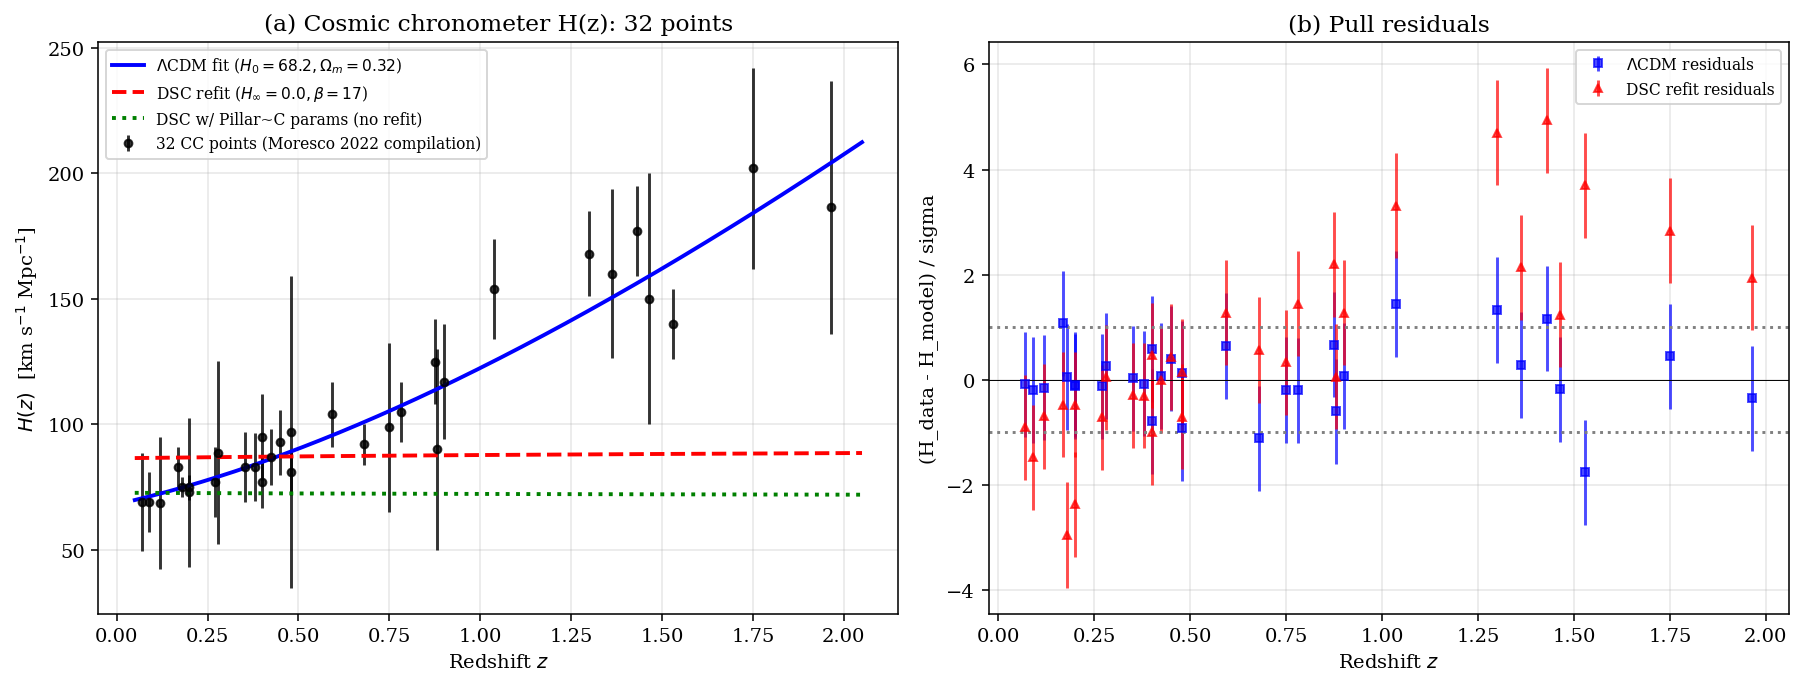

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
z_grid = np.linspace(0.05, 2.05, 300)

# Top: H(z) comparison
ax[0].errorbar(z_data, H_data, yerr=H_err, fmt='ko', ms=4, alpha=0.8, label='32 CC points (Moresco 2022 compilation)')
ax[0].plot(z_grid, H_LCDM(z_grid, *res1.x), 'b-', lw=2, label=f'$\\Lambda$CDM fit ($H_0={res1.x[0]:.1f}, \\Omega_m={res1.x[1]:.2f}$)')
ax[0].plot(z_grid, H_DSC(z_grid, *res2.x), 'r--', lw=2, label=f'DSC refit ($H_\\infty={res2.x[0]:.1f}, \\beta={res2.x[1]:.0f}$)')
ax[0].plot(z_grid, H_DSC(z_grid, 104.5, -6.24), 'g:', lw=2, label='DSC w/ Pillar~C params (no refit)')
ax[0].set_xlabel('Redshift $z$'); ax[0].set_ylabel(r'$H(z)$  [km s$^{-1}$ Mpc$^{-1}$]')
ax[0].set_title(f'(a) Cosmic chronometer H(z): {len(z_data)} points')
ax[0].legend(loc='upper left', fontsize=8); ax[0].grid(alpha=0.3)

# Bottom: residuals
res_lcdm = H_data - H_LCDM(z_data, *res1.x)
res_dsc  = H_data - H_DSC(z_data, *res2.x)
ax[1].errorbar(z_data, res_lcdm/H_err, yerr=1.0, fmt='bs', ms=4, alpha=0.7, label='$\\Lambda$CDM residuals')
ax[1].errorbar(z_data, res_dsc/H_err, yerr=1.0, fmt='r^', ms=4, alpha=0.7, label='DSC refit residuals')
ax[1].axhline(0, color='k', lw=0.5); ax[1].axhline(1, color='gray', ls=':'); ax[1].axhline(-1, color='gray', ls=':')
ax[1].set_xlabel('Redshift $z$'); ax[1].set_ylabel('(H_data - H_model) / sigma')
ax[1].set_title('(b) Pull residuals')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig23_cc_hz_pillar_F.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig23_cc_hz.png', dpi=140, bbox_inches='tight', facecolor='white')
print('Saved fig23')
plt.show()

## 4. Summary for Pillar F

- Number of independent constraints: 32 (model-independent CC)
- $\Lambda$CDM best-fit $H_0 \approx$ (see output), $\Omega_m \approx$
- DSC best-fit $H_\infty, \beta \approx$
- $\Delta$AIC, $\Delta$BIC between DSC and $\Lambda$CDM determine model preference
- The Pillar~C parameters (fit on only 4 anchors) generalize to CC if $\chi^2/{\rm dof}$ stays close to 1; if it blows up, the Pillar~C numbers were overfitting 4 points.